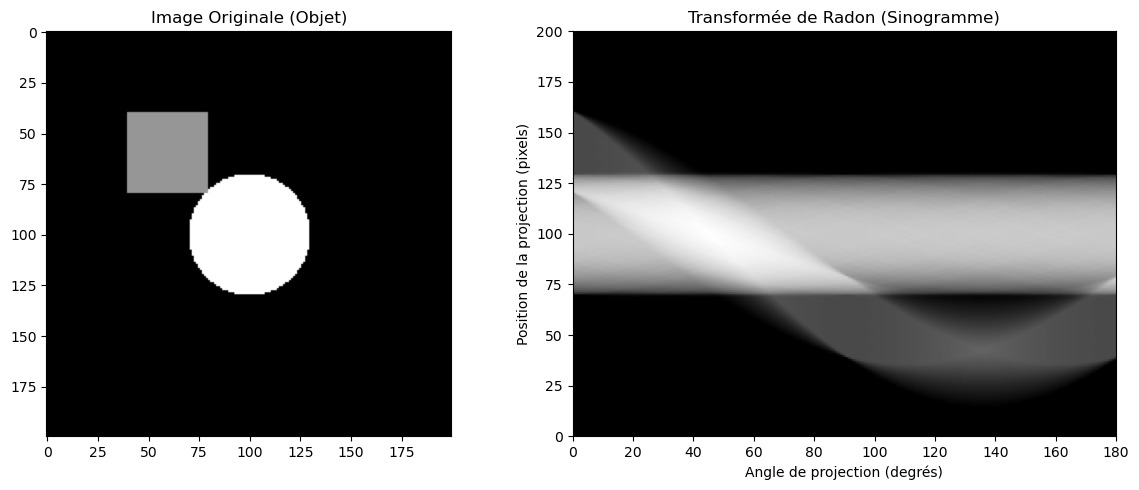

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon
from skimage.draw import disk, rectangle

# 1. Création d'une image test (fantôme)
image = np.zeros((200, 200))

# Ajout d'un cercle plein
rr, cc = disk((100, 100), 30)
image[rr, cc] = 1

# Ajout d'un carré
image[40:80, 40:80] = 0.5

# 2. Application de la Transformée de Radon
# On calcule les projections pour des angles allant de 0 à 180 degrés
angles = np.linspace(0., 180., max(image.shape), endpoint=False)
sinogramme = radon(image, theta=angles)

# 3. Affichage des résultats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Affichage de l'image originale
ax1.set_title("Image Originale (Objet)")
ax1.imshow(image, cmap=plt.cm.Greys_r)

# Affichage du sinogramme
ax2.set_title("Transformée de Radon (Sinogramme)")
ax2.set_xlabel("Angle de projection (degrés)")
ax2.set_ylabel("Position de la projection (pixels)")
# L'aspect 'auto' permet de bien voir l'image même si les axes n'ont pas la même taille
ax2.imshow(sinogramme, cmap=plt.cm.Greys_r, extent=(0, 180, 0, sinogramme.shape[0]), aspect='auto')

plt.tight_layout()
plt.show()

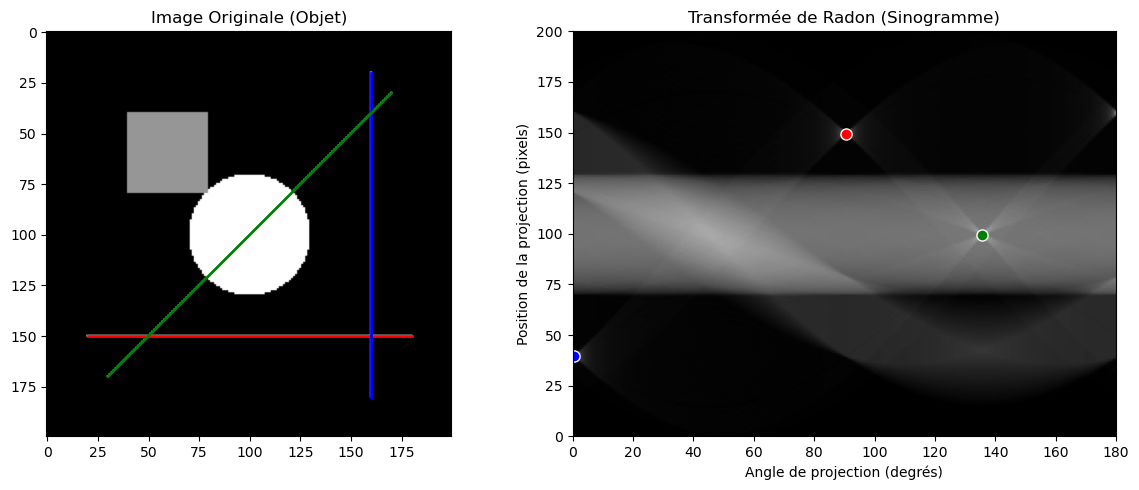

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import radon
from skimage.draw import disk, rectangle, line

# 1. Création d'une image test (fantôme)
image = np.zeros((200, 200))

# Ajout d'un cercle plein
rr, cc = disk((100, 100), 30)
image[rr, cc] = 1

# Ajout d'un carré
image[40:80, 40:80] = 0.5

# --- NOUVEAU : Définition et ajout de 3 droites ---
# Format : (ligne_début, col_début, ligne_fin, col_fin, couleur)
lignes = [
    (150, 20, 150, 180, 'red'),       # Ligne horizontale en bas
    (20, 160, 180, 160, 'blue'),      # Ligne verticale à droite
    (30, 170, 170, 30, 'green')       # Ligne diagonale
]

# Ajout des droites directement dans la matrice de l'image (en blanc)
for r0, c0, r1, c1, _ in lignes:
    rr, cc = line(r0, c0, r1, c1)
    image[rr, cc] = 1
# --------------------------------------------------

# 2. Application de la Transformée de Radon
# On calcule les projections pour des angles allant de 0 à 180 degrés
angles = np.linspace(0., 180., max(image.shape), endpoint=False)
sinogramme = radon(image, theta=angles)

# 3. Affichage des résultats
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Affichage de l'image originale
ax1.set_title("Image Originale (Objet)")
ax1.imshow(image, cmap=plt.cm.Greys_r)

# Affichage du sinogramme
ax2.set_title("Transformée de Radon (Sinogramme)")
ax2.set_xlabel("Angle de projection (degrés)")
ax2.set_ylabel("Position de la projection (pixels)")
# L'aspect 'auto' permet de bien voir l'image même si les axes n'ont pas la même taille
ax2.imshow(sinogramme, cmap=plt.cm.Greys_r, extent=(0, 180, 0, sinogramme.shape[0]), aspect='auto')

# --- NOUVEAU : Coloration des droites et de leurs points correspondants ---
for r0, c0, r1, c1, couleur in lignes:
    # 1. Tracer la droite en couleur sur l'image de gauche (ax1)
    # Note : matplotlib plot utilise (x, y) soit (colonnes, lignes)
    ax1.plot([c0, c1], [r0, r1], color=couleur, linewidth=2)

    # 2. Trouver le point correspondant dans le sinogramme
    # Astuce : on calcule la transformée de Radon de CETTE seule droite pour isoler son pic
    image_temporaire = np.zeros_like(image)
    rr, cc = line(r0, c0, r1, c1)
    image_temporaire[rr, cc] = 1
    sino_temporaire = radon(image_temporaire, theta=angles)

    # L'endroit où l'accumulation est maximale correspond à la signature de notre droite
    rho_idx, theta_idx = np.unravel_index(np.argmax(sino_temporaire), sino_temporaire.shape)

    # 3. Calculer les coordonnées exactes pour l'affichage (calibré avec "extent")
    x_plot = 180.0 * (theta_idx + 0.5) / len(angles)
    y_plot = sinogramme.shape[0] - rho_idx - 0.5

    # 4. Dessiner le point sur le sinogramme (ax2)
    ax2.plot(x_plot, y_plot, marker='o', color=couleur, markersize=8, markeredgecolor='white', markeredgewidth=1)
# --------------------------------------------------------------------------

plt.tight_layout()
plt.show()